In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from os.path import basename

In [2]:
db_file = "desi_3040_v5.3.1_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)

reg_visit = ["ToO" not in note and "twili" not in note for note in visits_array["scheduler_note"]]

# If we want to use some automated label generation 
arrays = []
infos = []
for filtername in ["u", "g", "r", "y"]:
    info = {"run_name": run_name}
    sub_data = visits_array[np.where((visits_array["band"] == filtername) & (reg_visit))]
    info['observations_subset'] = "filter=%s, no ToO or twilight" % (filtername)
    sl = maf.Slicer()
    times = np.arange(3653)
    metric = maf.AccumulateCountMetric(times)
    #metric = maf.CountMetric()
    # Run the metics through the slicer
    hp_array, info = sl(sub_data, metric, info=info)
    arrays.append(hp_array)
    infos.append(info)




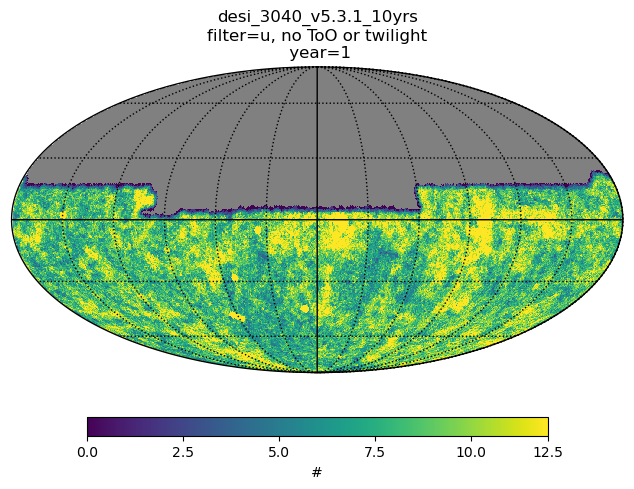

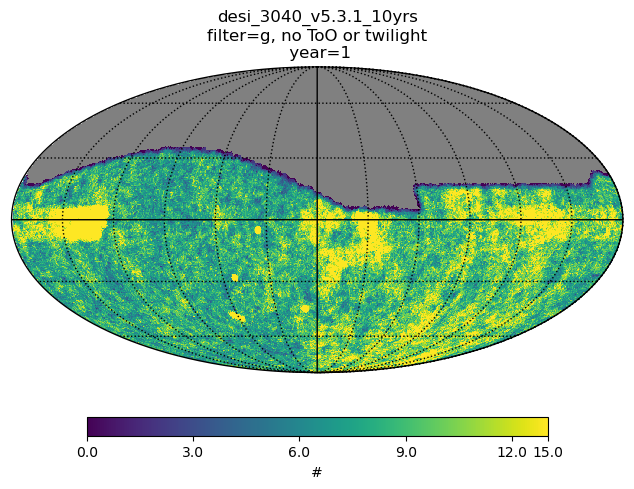

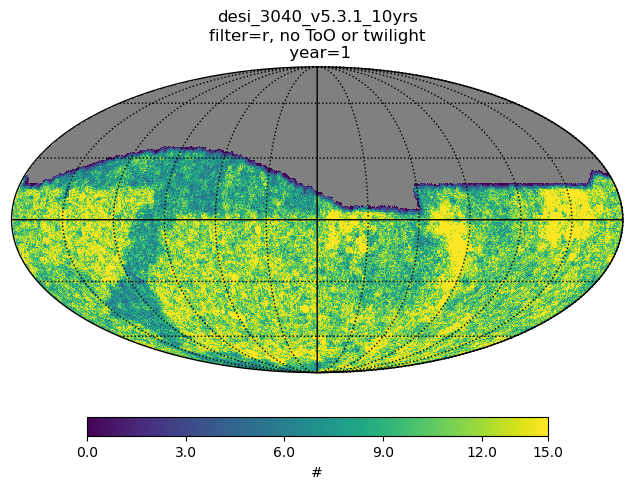

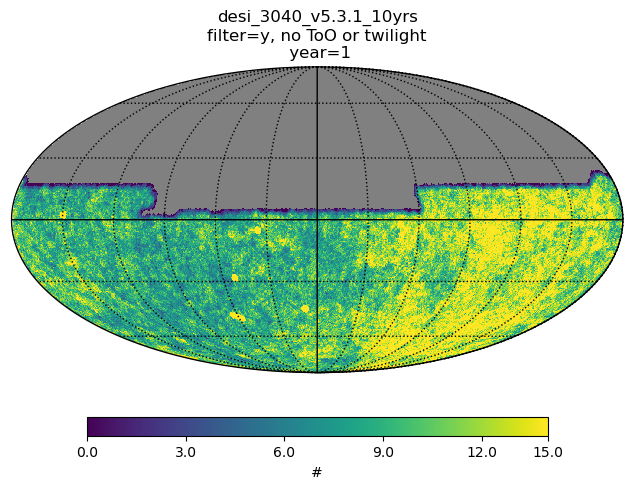

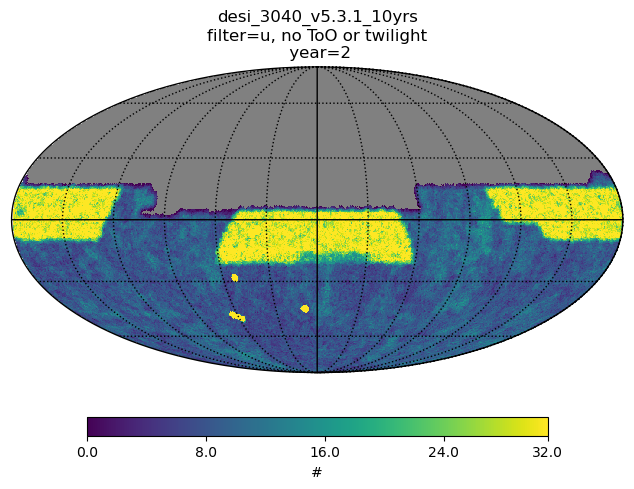

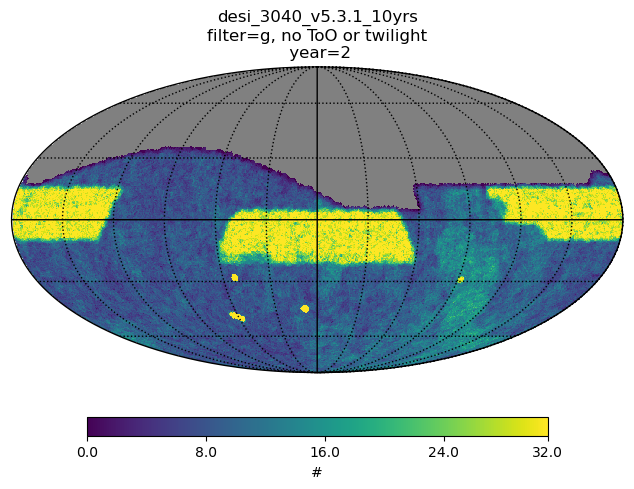

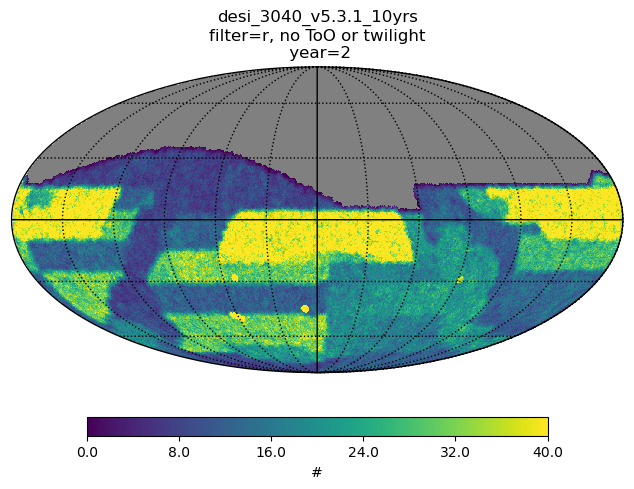

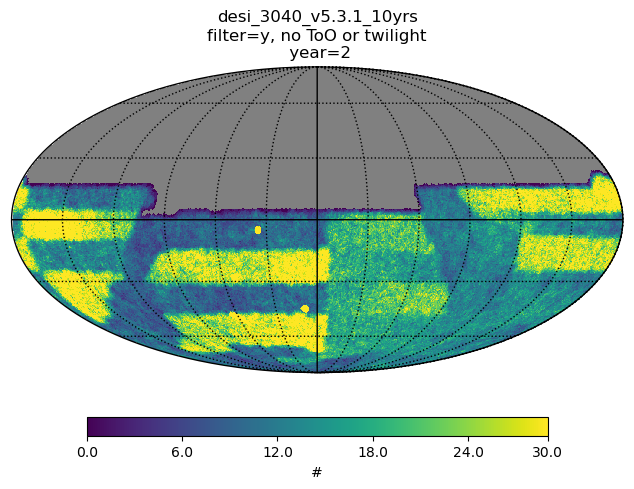

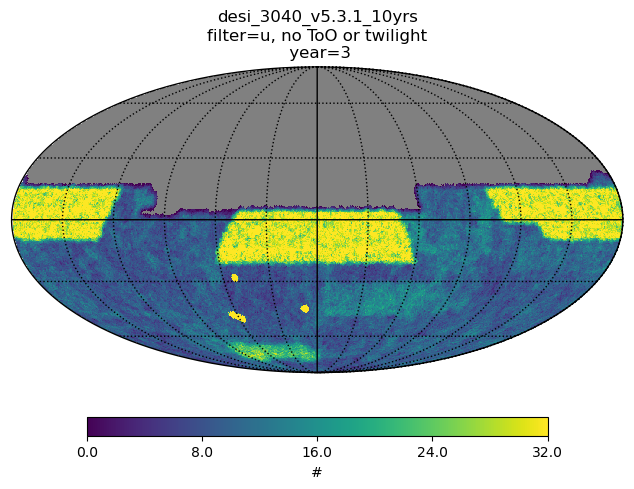

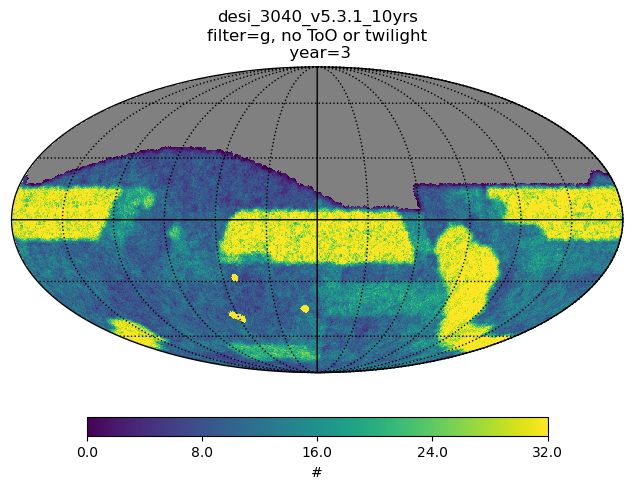

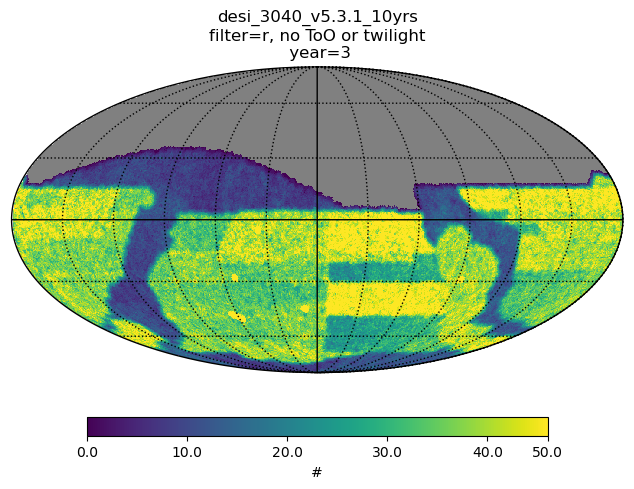

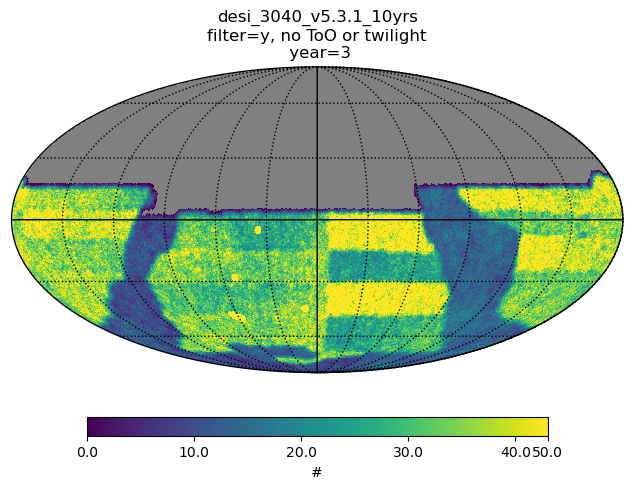

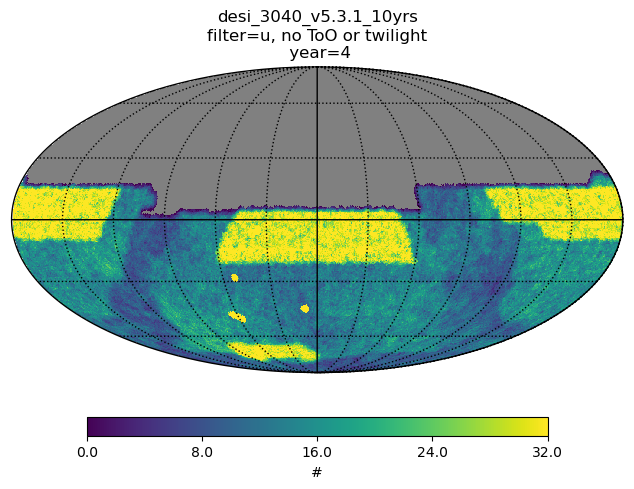

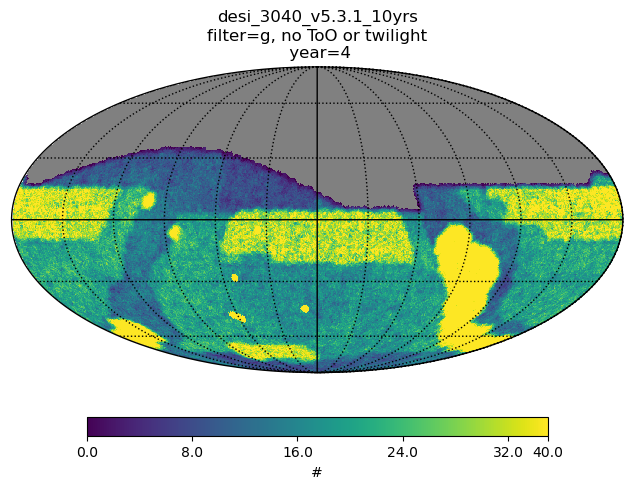

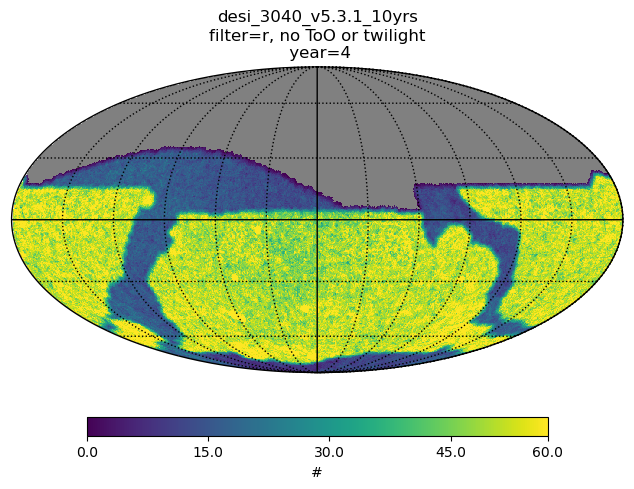

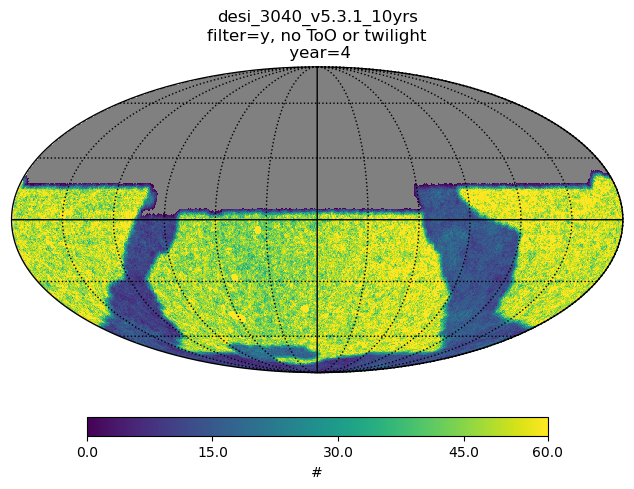

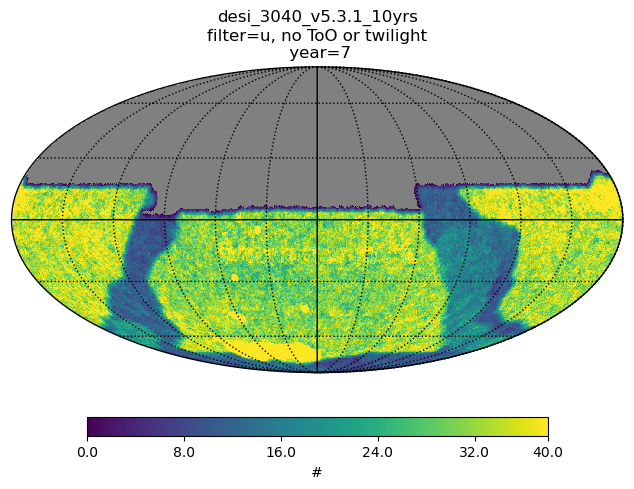

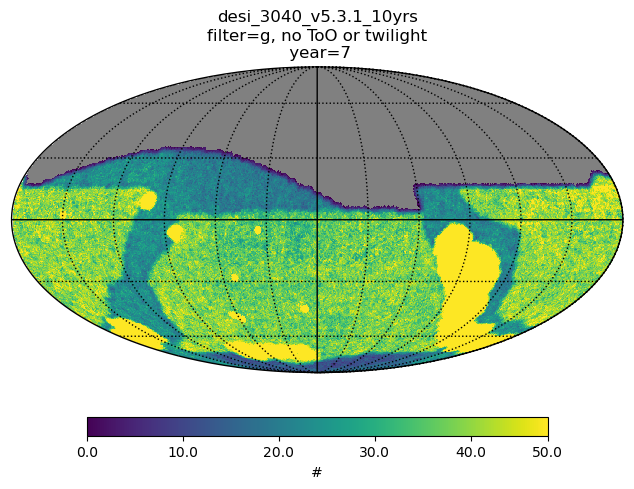

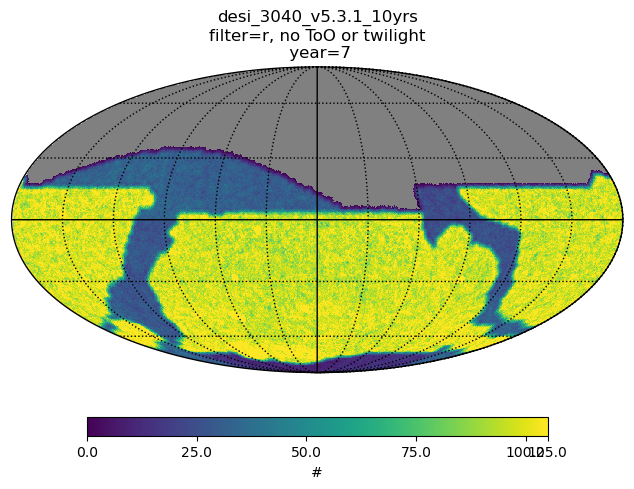

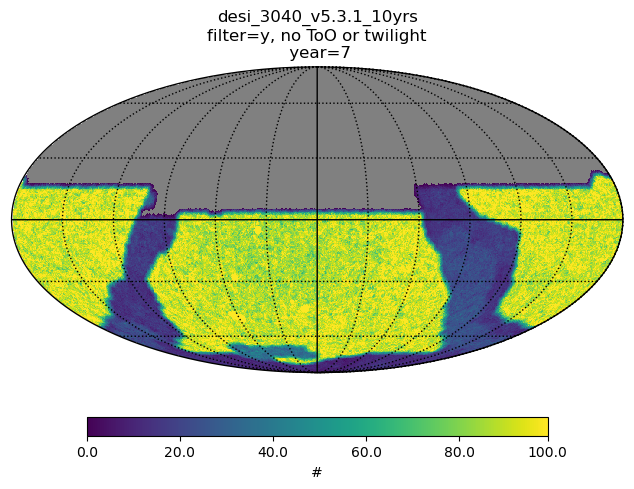

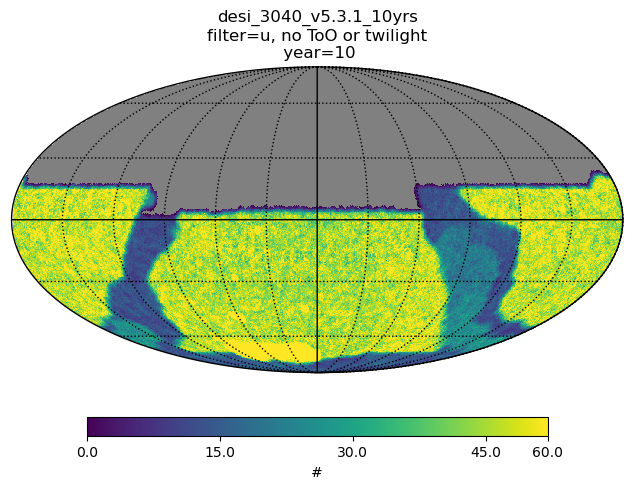

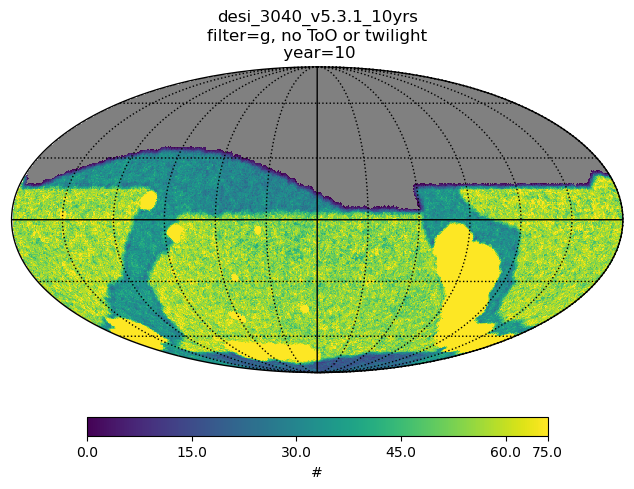

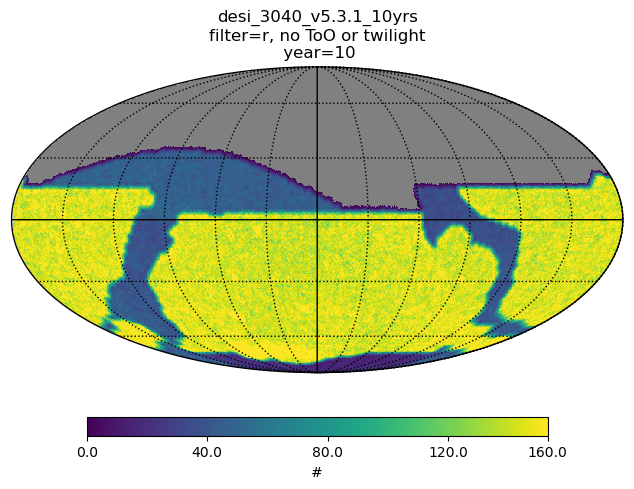

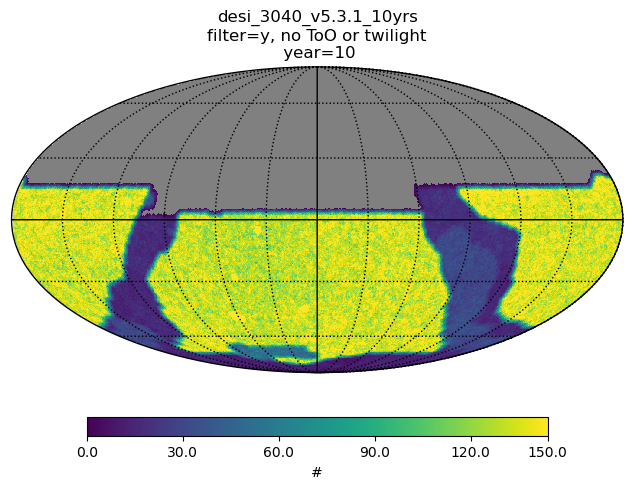

In [3]:
years = [1,2,3,4,7,10]
for year in years:
    for hp_array,info in zip(arrays, infos):
        pm = maf.PlotMoll(info=info)
        val = hp_array[:, 365*year]
        default_labels = pm._gen_default_labels(info)
        fig = pm(val, max=np.percentile(val[np.isfinite(val)], 90),
                 title=default_labels["title"]+'\n year=%i' % year)

In [4]:
# grab all the pointings by a positions
ra = 0
dec = 0
sl = maf.Slicer(ra=ra, dec=dec, nside=None)
visits_at_point = sl(visits_array[reg_visit], maf.PassMetric())
visits_at_point.sort(order="night")

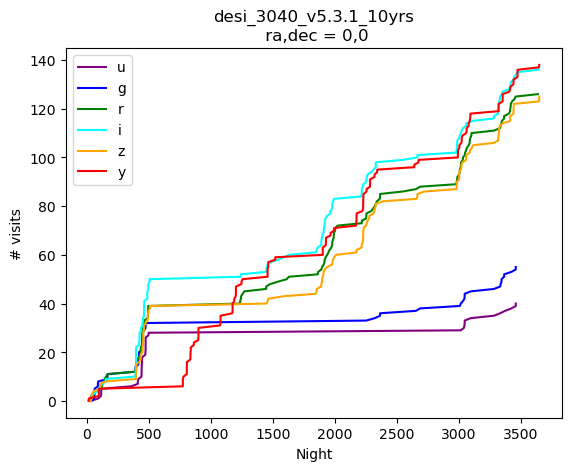

In [5]:
fig, ax = plt.subplots()
f2c = {'u': 'purple', 'g': 'blue', 'r': 'green',
       'i': 'cyan', 'z': 'orange', 'y': 'red'}
for bandname in "ugrizy":
    inband = np.where(visits_at_point["band"] == bandname)[0]
    ax.plot(visits_at_point["night"][inband], np.arange(inband.size), label=bandname, color=f2c[bandname])
ax.set_xlabel("Night")
ax.set_ylabel("# visits")
ax.set_title(run_name + "\n ra,dec = 0,0")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)

In [6]:
# grab all the pointings by a positions
ra = 0
dec = -40
sl = maf.Slicer(ra=ra, dec=dec, nside=None)
visits_at_point = sl(visits_array[reg_visit], maf.PassMetric())
visits_at_point.sort(order="night")

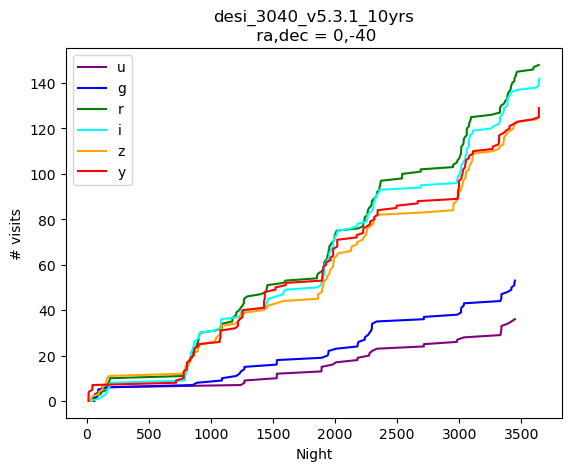

In [7]:
fig, ax = plt.subplots()
for bandname in "ugrizy":
    inband = np.where(visits_at_point["band"] == bandname)[0]
    ax.plot(visits_at_point["night"][inband], np.arange(inband.size), label=bandname, color=f2c[bandname])
ax.set_xlabel("Night")
ax.set_ylabel("# visits")
ax.set_title(run_name + "\n ra,dec = 0,-40")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels)